### E-commerce Landing Page Conversion Optimization using A/B Testing

#### An e-commerce company wants to test a new landing page design.

#### Goal:

#### Determine whether the new landing page increases purchase conversion rate.

In [30]:
import pandas as pd

In [31]:
df = pd.read_csv('ab_data.csv')

In [32]:
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [34]:
df.shape

(294478, 5)

In [35]:
df.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [36]:
df.duplicated(subset='user_id').sum()

np.int64(3894)

In [37]:
df = df.drop_duplicates(subset='user_id')

In [38]:
df['group'].value_counts()

group
treatment    145352
control      145232
Name: count, dtype: int64

In [39]:
pd.crosstab(df['group'],df['landing_page'])

landing_page,new_page,old_page
group,,
control,1006,144226
treatment,144314,1038


In [40]:
df = df[((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
        ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))] 


In [41]:
df['converted'] = df['converted'].astype(int)

In [42]:
df.shape
# df.head()

(288540, 5)

## EDA
What is the overall conversion rate?
Which group performs better?
Are the groups balanced?
What patterns exist in the data?

In [43]:
df['converted'].mean()

np.float64(0.11950856033825466)

In [44]:
df.groupby('group')['converted'].mean()

# new page conversions we got 11.8%

group
control      0.120290
treatment    0.118727
Name: converted, dtype: float64

In [47]:
df['group'].value_counts()

group
treatment    144314
control      144226
Name: count, dtype: int64

array(['control', 'treatment'], dtype=object)

In [49]:
pd.crosstab(df['group'], df['converted'])

converted,0,1
group,,
control,126877,17349
treatment,127180,17134


In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

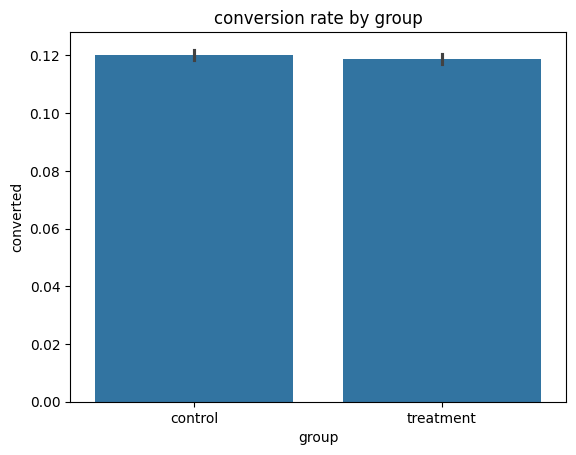

In [58]:
sns.barplot(x='group',y ='converted', data = df)
plt.title("conversion rate by group")
plt.show()

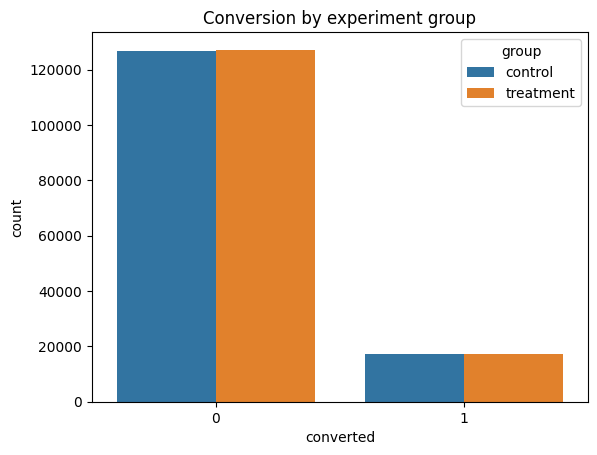

In [59]:
# distribution of converted users
sns.countplot(x = 'converted', hue='group', data= df)
plt.title("Conversion by experiment group")
plt.show()

The control group shows a slightly higher conversion rate compared to the treatment group. However, the difference appears small and requires statistical testing to determine whether it is significant or due to random variation.

Step 4 — Statistical Hypothesis Testing (Two-Proportion Z-Test)

we must determine:

Is the difference between control and treatment statistically significant or just random chance?

Null Hypothesis (H₀)
The new landing page does not improve conversion rate.

Alternative Hypothesis (H₁)
The new landing page improves conversion rate.

In [60]:
control = df[df['group']=='control']['converted']
treatment = df[df['group']=='treatment']['converted']

In [61]:
control_conversions = control.sum()
treatment_conversions = treatment.sum()

In [62]:
control_users = len(control)
treatment_users = len(treatment)

In [63]:
print(control_conversions,control_users)
print(treatment_conversions,treatment_users)

17349 144226
17134 144314


In [64]:
pip install statsmodels  

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Jaikishan\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [66]:
# Run the Two-Proportion Z-Test

from statsmodels.stats.proportion import proportions_ztest

count = [treatment_conversions,control_conversions]
nobs = [treatment_users, control_users]

z_stat, p_value = proportions_ztest(count,nobs)

print("Z-statistics",z_stat)
print("p-value", p_value)


Z-statistics -1.2942367891190543
p-value 0.19558364287881436


Since the p-value is greater than 0.05, we fail to reject the null hypothesis.
This means the new landing page does not significantly improve conversion rates.

Experiment Result

Control conversion rate ≈ 12.0%

Treatment conversion rate ≈ 11.8%

Statistical test shows no significant improvement

Recommendation

The new landing page should not be deployed, as it does not provide a statistically significant improvement in conversion rate.

Step 5

Why did the experiment perform this way?

In [68]:
df.groupby('landing_page')['converted'].mean()*100

landing_page
new_page    11.872722
old_page    12.029038
Name: converted, dtype: float64

The old landing page performs slightly better than the new landing page.

In [69]:
pd.crosstab(df['converted'], df['group'])

group,control,treatment
converted,,
0,126877,127180
1,17349,17134


In [70]:
control_rate = df[df['group']=='control']['converted'].mean()
treatment_rate = df[df['group']=='treatment']['converted'].mean()

difference = treatment_rate - control_rate

print("Conversion Difference:", difference)

Conversion Difference: -0.0015631577894657384


new page performs 0.1 worse

Experiment Insight

The control group shows a slightly higher conversion rate than the treatment group.

The difference between the two groups is very small.

Statistical testing confirmed that the difference is not significant.

Recommendation

The new landing page should not replace the current page, as it does not significantly improve conversion rates.

In [71]:
pip install pymysql sqlachemy

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: pymysql in c:\users\jaikishan\appdata\local\programs\python\python310\lib\site-packages (1.1.2)



ERROR: Could not find a version that satisfies the requirement sqlachemy (from versions: none)
ERROR: No matching distribution found for sqlachemy
You should consider upgrading via the 'c:\Users\Jaikishan\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [72]:
pip install cryptography

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Jaikishan\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [76]:
from sqlalchemy import create_engine

In [81]:
from urllib.parse import quote_plus
# MYSQL connection
username = "root"
password = quote_plus("J@ikishan08")
host = "localhost"
port = "3306"
database = "ab_testing"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# write Dataframe to MYSQL
table_name = "page"
df.to_sql(table_name,engine,if_exists="replace",index=False)

pd.read_sql("select * from page limit 5;",engine)

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1
